# Estimating Probability of Default (PD)

---

Author: José Reyes

Probability of Default Modeling

**Difficulty**

🟡 Intermediate

**Estimated Reading Time**

45–60 minutes

**Prerequisites**

- Notebook 01 — Credit Scoring Fundamentals
- Notebook 02 — Building an Educational Credit Score

---

> "A credit score summarizes a customer's financial profile.
>
> A Probability of Default estimates the likelihood that the customer will fail to repay a loan."

## Educational Note

---

> This notebook implements an **educational Probability of Default (PD) model** inspired by the methodologies commonly used by banks and financial institutions.

The mathematical formulation is based on **Logistic Regression**, one of the most widely used statistical models in Credit Risk.

However, the coefficients used throughout this notebook are **manually calibrated for learning purposes** and **have not been estimated from historical banking data**.

In production environments, financial institutions estimate these coefficients using **millions of historical loans**, default events, and customer behavioral variables.

Our objective is to understand the mathematics and business logic behind PD estimation before exploring Machine Learning models in future projects.

## 1. Learning Objectives

After completing this notebook you will be able to:

- Understand the concept of Probability of Default (PD)
- Differentiate Credit Score from Probability of Default
- Understand why banks use Logistic Regression
- Interpret the Logistic Function
- Build an educational Probability of Default model
- Apply Probability of Default to customer datasets
- Interpret PD as a business metric

## 3. Business Context

Imagine that two customers apply for exactly the same loan.

Both customers:

- Request \$350,000
- Earn similar monthly incomes
- Have similar employment histories

However...

One customer will repay the loan successfully.

The other customer will eventually default.

How can a financial institution estimate this risk **before approving the loan?**

This is the purpose of the **Probability of Default (PD)**.

Rather than classifying customers as "good" or "bad", banks estimate the probability that each customer may default in the future.

This probability becomes one of the most important metrics in Credit Risk Management.

## 4. Credit Score vs Probability of Default

Although both concepts are closely related, they answer different business questions.

| Credit Score | Probability of Default |
|--------------|-----------------------|
| Measures customer credit quality | Estimates future default risk |
| Usually ranges from 400–850 | Probability between 0 and 1 |
| Business-friendly metric | Statistical metric |
| Easier to communicate | Used for quantitative risk modeling |

In practice, a higher Credit Score generally corresponds to a lower Probability of Default, although they are not mathematically equivalent.

## 5. How Do Banks Estimate Probability of Default?

Banks do not assign probabilities arbitrarily.

Instead, they rely on historical loan portfolios containing millions of observations.

Each historical loan includes:

- Customer characteristics
- Credit behavior
- Loan information
- Repayment history
- Whether the customer eventually defaulted

Using these historical observations, banks train statistical models capable of learning the relationship between customer characteristics and future defaults.

One of the most common techniques is **Logistic Regression**.

The trained model estimates coefficients that maximize the probability of correctly predicting historical default events.

These coefficients are periodically recalibrated as customer behavior and economic conditions change.

## 6. Typical Variables Used in PD Models

Although every financial institution develops its own proprietary models, many Probability of Default models use variables such as:

### Customer Characteristics

- Age
- Monthly Income
- Employment Stability
- Debt-to-Income Ratio

### Credit Bureau Variables

- Credit Score
- Payment History
- Credit Utilization
- Credit History Length
- Credit Mix
- Recent Credit Inquiries

### Loan Variables

- Loan Amount
- Down Payment
- Loan-to-Value Ratio
- Interest Rate
- Loan Term

### Macroeconomic Variables

- Inflation
- Unemployment
- GDP Growth
- Interest Rate Environment

Each institution selects and engineers variables according to its own historical data and business strategy.

## 7. Why Logistic Regression?

Suppose we attempted to estimate a Probability of Default using Linear Regression.

The resulting prediction could be:

- PD = -0.18
- PD = 1.34

Neither value is a valid probability.

Probabilities must always remain between **0** and **1**.

To solve this problem, banks commonly use the **Logistic Function**, which naturally constrains predictions within this interval.

## 8. Mathematical Model

The Logistic Function transforms any real-valued number into a probability.

$\ PD=\frac{1}{1+e^{-z}}$

Where:

- **PD** represents the Probability of Default.
- **z** is a linear combination of customer variables.
- **e** is Euler's constant.

The resulting probability always lies between **0** and **1**.

### 8.1 The Logit Equation

The value of \(z\) is calculated as

$\ z=\beta_0+\beta_1x_1+\beta_2x_2+\cdots+\beta_nx_n$

Where:

- $\beta_0$ is the intercept.
- $\beta_i$ are model coefficients.
- $\ x_i$ are customer characteristics.

During model training, banks estimate these coefficients using historical customer data.

In this notebook we will manually define educational coefficients in order to simulate this process.

### 8.2. Our Educational Probability of Default Model

Throughout this notebook we will estimate PD using the same customer information developed in the previous notebook.

The educational model considers five behavioral variables:

- Payment History
- Credit Utilization
- Credit History Length
- Credit Mix
- Recent Credit Activity

Instead of training coefficients using millions of observations, we will manually calibrate them to produce realistic educational probabilities.

This approach allows us to understand the complete modeling process while keeping the implementation transparent.

In [69]:
import pandas as pd

from src.credit_score import *

# Setting the DF 
customers = pd.DataFrame({
    "Customer": [
        "Carlos",
        "Andrea",
        "Luis",
        "María"
    ],
    "Late_Payments": [0, 4, 2, 1],
    "Credit_Utilization": [22, 91, 48, 35],
    "Credit_History_Years": [11, 2, 6, 9],
    "Credit_Mix": [3, 1, 2, 4],
    "Recent_Inquiries": [0, 5, 2, 1]
})

In [70]:
# Calculating their credit score with the src/scredit_score.py
customers["PH"] = (customers["Late_Payments"].apply(payment_history_score))
customers["CU"] = (customers["Credit_Utilization"].apply(utilization_score))
customers["CH"] = (customers["Credit_History_Years"].apply(credit_history_score))
customers["CM"] = (customers["Credit_Mix"].apply(credit_mix_score))
customers["RA"] = (customers["Credit_Mix"].apply(recent_activity_score))

# Raw Score
customers["Raw_Score"] = customers.apply(calculate_raw_score,axis=1)

# Calculating Credit Score
customers["Credit_Score"] = (customers["Raw_Score"].apply(normalize_credit_score))

customers

,Customer,Late_Payments,Credit_Utilization,Credit_History_Years,Credit_Mix,Recent_Inquiries,PH,CU,CH,CM,RA,Raw_Score,Credit_Score
0,Carlos,0,22,11,3,0,100,100,100,80,60,98.00,841
1,Andrea,4,91,2,1,5,20,25,60,40,90,30.50,537
2,Luis,2,48,6,2,2,75,80,80,60,75,75.75,741
3,María,1,35,9,4,1,90,80,80,100,30,86.50,789


In [71]:
# Rebuilding customers df without credit score variables
customers = pd.concat([customers.iloc[:,0:6], customers["Credit_Score"]], axis=1)
customers

,Customer,Late_Payments,Credit_Utilization,Credit_History_Years,Credit_Mix,Recent_Inquiries,Credit_Score
0,Carlos,0,22,11,3,0,841
1,Andrea,4,91,2,1,5,537
2,Luis,2,48,6,2,2,741
3,María,1,35,9,4,1,789


### 8.3 From Mathematical Theory to Python

In the previous sections we introduced the mathematical foundations behind Probability of Default.

Rather than implementing these equations directly inside the notebook, we will rely on a dedicated business module located in:

```text
src/
└── pd_model.py
```

This architecture separates:

- Financial theory
- Mathematical implementation
- Business logic

making the project easier to maintain and reuse throughout the Credit Risk Fundamentals project.

In [72]:
from src.pd_model import (
    calculate_logit,
    logistic_function,
    probability_of_default,
    classify_pd
)

#### Step 1: Calculating the Logit

The first step consists of computing the **linear predictor**, commonly referred to as the **logit**.

Mathematically,

$\ z=\beta_0+\beta_1x_1+\beta_2x_2+\cdots+\beta_nx_n$

The logit is **not yet a probability**.

Instead, it summarizes the combined effect of all customer variables before applying the Logistic Function.

In [73]:
customers["Logit"] = customers.apply(calculate_logit, axis=1)
customers

,Customer,Late_Payments,Credit_Utilization,Credit_History_Years,Credit_Mix,Recent_Inquiries,Credit_Score,Logit
0,Carlos,0,22,11,3,0,841,-3.604
1,Andrea,4,91,2,1,5,537,1.048
2,Luis,2,48,6,2,2,741,-1.496
3,María,1,35,9,4,1,789,-2.800


Notice that the calculated **Logit** can take **any real value**, including positive and negative numbers.

For this reason, the Logit cannot be interpreted directly as a Probability of Default.

The Logistic Function will transform these values into valid probabilities between 0 and 1.

#### Step 2: Applying the Logistic Function

Once the Logit has been calculated, we estimate the Probability of Default using the Logistic Function.

$\ PD=\frac{1}{1+e^{-z}}$

This mathematical transformation guarantees that every prediction remains between **0 and 1**, making it suitable for probability estimation.

In [74]:
customers["PD"] = (customers["Logit"].apply(logistic_function))
customers

,Customer,Late_Payments,Credit_Utilization,Credit_History_Years,Credit_Mix,Recent_Inquiries,Credit_Score,Logit,PD
0,Carlos,0,22,11,3,0,841,-3.604,0.026494
1,Andrea,4,91,2,1,5,537,1.048,0.740391
2,Luis,2,48,6,2,2,741,-1.496,0.183023
3,María,1,35,9,4,1,789,-2.800,0.057324


The resulting values now represent estimated default probabilities.

For example:

| PD | Interpretation |
|----|----------------|
| 0.02 | Approximately 2% probability of default |
| 0.15 | Approximately 15% probability of default |
| 0.45 | Approximately 45% probability of default |

Higher probabilities indicate greater expected credit risk.

#### Step 3: One-Step Probability Estimation

Since calculating the Logit and applying the Logistic Function always occur together, our module provides a convenience function:

```python
probability_of_default(customer)
```

This function internally performs both calculations and returns the final Probability of Default.

In [75]:
customers["Probability_of_Default"] = (customers.apply(probability_of_default,axis=1))
customers

,Customer,Late_Payments,Credit_Utilization,Credit_History_Years,Credit_Mix,Recent_Inquiries,Credit_Score,Logit,PD,Probability_of_Default
0,Carlos,0,22,11,3,0,841,-3.604,0.026494,0.026494
1,Andrea,4,91,2,1,5,537,1.048,0.740391,0.740391
2,Luis,2,48,6,2,2,741,-1.496,0.183023,0.183023
3,María,1,35,9,4,1,789,-2.800,0.057324,0.057324


#### Step 4: Risk Classification

Business users rarely work directly with raw probabilities.

Instead, financial institutions usually classify customers into qualitative risk categories.

Our educational model defines the following buckets.

| Probability of Default | Risk Category |
| ---------------------: | ------------- |
|                    <5% | Very Low      |
|                  5–15% | Low           |
|                 15–30% | Medium        |
|                 30–50% | High          |
|                   >50% | Very High     |


In [76]:
customers["Risk_Category"] = (customers["Probability_of_Default"].apply(classify_pd))
customers

,Customer,Late_Payments,Credit_Utilization,Credit_History_Years,Credit_Mix,Recent_Inquiries,Credit_Score,Logit,PD,Probability_of_Default,Risk_Category
0,Carlos,0,22,11,3,0,841,-3.604,0.026494,0.026494,Very Low
1,Andrea,4,91,2,1,5,537,1.048,0.740391,0.740391,Very High
2,Luis,2,48,6,2,2,741,-1.496,0.183023,0.183023,Medium
3,María,1,35,9,4,1,789,-2.800,0.057324,0.057324,Low


Risk buckets simplify communication across the organization.

Rather than discussing exact probabilities, decision-makers can quickly identify customers belonging to different risk segments.

## 9. Final Results

The complete educational Probability of Default model now provides four different outputs:

- Logit
- Probability of Default
- Risk Category
- Customer Profile

These outputs will become key inputs for future lending decisions.

In [77]:
customers

,Customer,Late_Payments,Credit_Utilization,Credit_History_Years,Credit_Mix,Recent_Inquiries,Credit_Score,Logit,PD,Probability_of_Default,Risk_Category
0,Carlos,0,22,11,3,0,841,-3.604,0.026494,0.026494,Very Low
1,Andrea,4,91,2,1,5,537,1.048,0.740391,0.740391,Very High
2,Luis,2,48,6,2,2,741,-1.496,0.183023,0.183023,Medium
3,María,1,35,9,4,1,789,-2.800,0.057324,0.057324,Low


## 10. Visualizing Probability of Default

Numerical values provide precise information.

However, visualizations allow us to identify patterns much more easily.

In this section we will explore how Probability of Default changes across different customers.

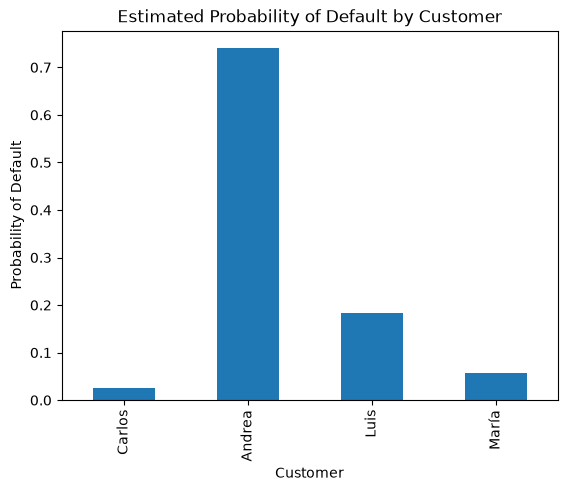

In [78]:
import matplotlib.pyplot as plt

customers.plot(
    x="Customer",
    y="Probability_of_Default",
    kind="bar",
    legend=False
)

plt.ylabel("Probability of Default")
plt.title("Estimated Probability of Default by Customer")

plt.show()

## 11. Relationship Between Credit Score and Probability of Default

One of the most important properties of the Logistic Function is that it creates a **non-linear relationship** between Credit Score and Probability of Default.

Customers with high scores experience very small changes in PD.

Conversely, customers with poor credit profiles exhibit rapidly increasing probabilities of default.

This S-shaped behavior is one of the defining characteristics of Logistic Regression.

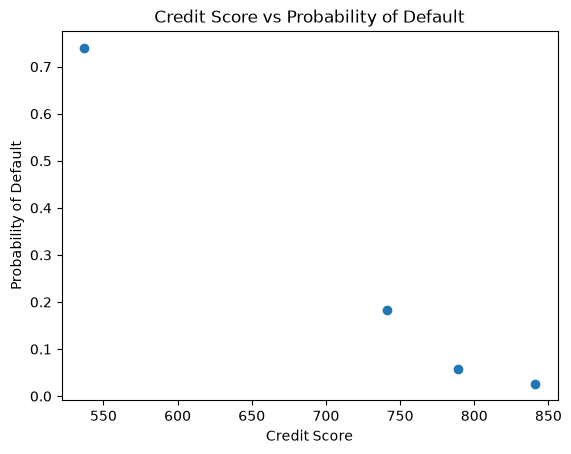

In [79]:
plt.scatter(customers["Credit_Score"],customers["Probability_of_Default"])
plt.xlabel("Credit Score")
plt.ylabel("Probability of Default")
plt.title("Credit Score vs Probability of Default")
plt.show()

The inverse relationship between Credit Score and Probability of Default is one of the most important concepts in Credit Risk.

Generally speaking:

- Higher Credit Scores correspond to lower default probabilities.
- Lower Credit Scores correspond to higher default probabilities.

Although our educational model uses manually calibrated coefficients, the resulting behavior closely resembles the intuition behind real-world credit risk models.

## 12. Executive Summary

Throughout this notebook we introduced the concept of Probability of Default (PD), one of the fundamental metrics in modern Credit Risk Management.

Starting from the Logistic Function, we:

- Explained why Logistic Regression is widely used in banking.
- Introduced the Logit equation.
- Built an educational Probability of Default model.
- Applied the model to customer data.
- Classified customers into qualitative risk buckets.

Although the coefficients used in this notebook were manually calibrated, the mathematical formulation mirrors the methodology commonly employed by financial institutions.

## 13. What's Next?

In the next notebook we will transform analytical outputs into business decisions.

Using both the Educational Credit Score and the Probability of Default developed throughout this project, we will build a **Loan Decision Engine** capable of simulating how a financial institution may:

- Approve or reject loan applications.
- Assign credit limits.
- Estimate interest rates.
- Support consistent lending decisions.

These components will later be integrated into an interactive Credit Approval Simulator.